In [ ]:
import glob
import os
import h5py
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200 # User can set this outside the class if needed

from astropy.io import fits
from astropy.io.votable import parse_single_table
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u

import os
import h5py
from tqdm import tqdm
from multiprocessing import Pool 
from concurrent.futures import ProcessPoolExecutor, as_completed, ThreadPoolExecutor
import numpy as np

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.table import Table

from reproject import reproject_interp
from reproject import reproject_exact
from reproject import reproject_adaptive

from scipy.sparse import coo_matrix
from scipy.sparse.linalg import lsqr
import sys 
import gc 
from functools import partial
from IPython.display import clear_output

from SelfCal.MapHelper import bit_to_bool, make_weight, find_outliers, map_pixels
from SelfCal.WCSHelper import load_from_fits, save_to_fits, find_optimal_frame
from SelfCal import MakeMap
from SelfCal.SPHERExUtility import make_fiducial_chunk_map, make_fiducial_chunk_mask, interpolate_array, load_calibration, interp_2d_vertical, interp_1d
import importlib
importlib.reload(MakeMap)

from datetime import datetime
import pandas as pd


In [ ]:
ch_list = np.arange(19, 33)
data_list = []
wav_list = []
for ch in tqdm(ch_list):
    mosaic_path = f'/mnt/md124/thomasli/selfcal/outputs/nep_det4_3p1arcsec/mosaic/mosaic_34channels_D4_Ch{ch}.fits'
    with fits.open(mosaic_path) as hdul:
        data = hdul[5].data
        wav = hdul[7].data
    
    data_list.append(data)
    wav_list.append(wav)

data_cube = np.stack(data_list, axis=0)
wav_cube = np.stack(wav_list, axis=0)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 145.46it/s]


In [46]:
data_cube.shape

(14, 17404, 18268)

In [ ]:
np.nonzero(data_cube)

In [ ]:
np.mean(data_cube]

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

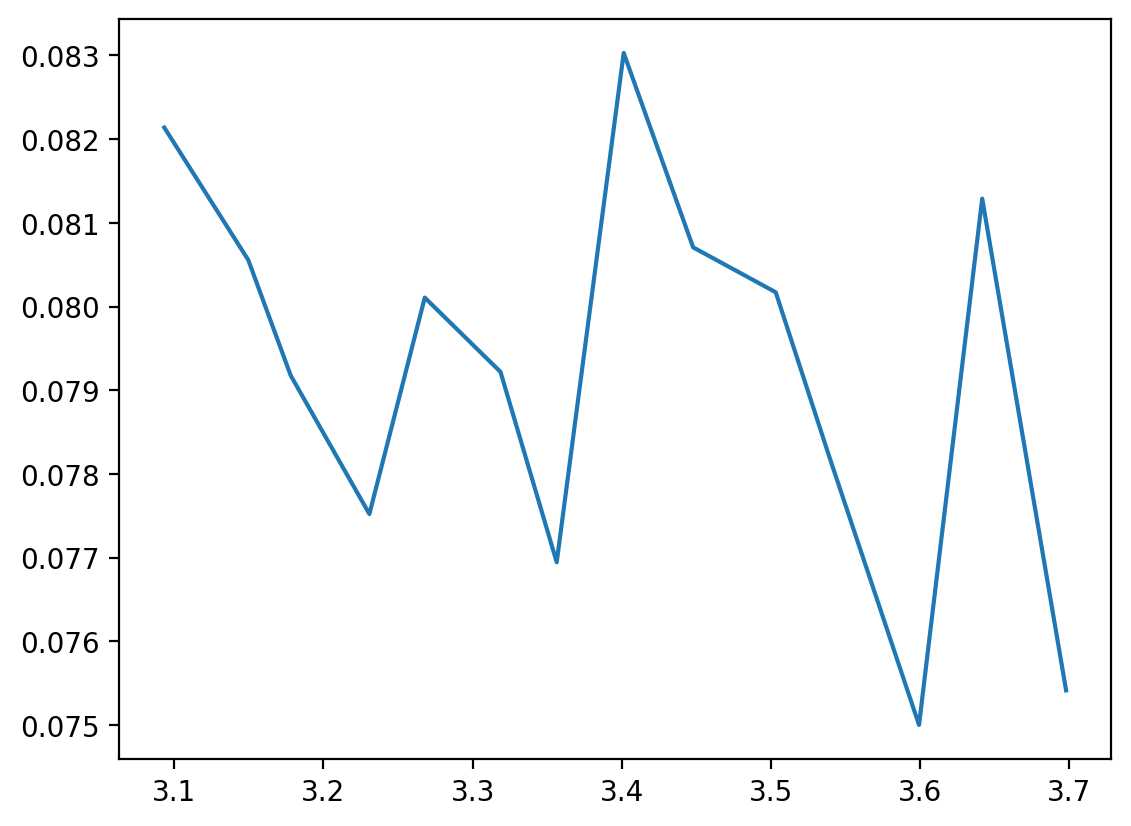

In [48]:
plt.plot(wav_cube[:,10000,10000], data_cube[:,10000,10000])

In [42]:
wav_edges = np.linspace(3, 4.2, 1200)  # Example wavelength edges from 0.75 to 5.0 microns
wav_med = 0.5 * (wav_edges[:-1] + wav_edges[1:])

hist_cube = np.zeros((wav_cube.shape[0], len(wav_med)))
for i in tqdm(range(wav_cube.shape[0])):
    hist, _ = np.histogram(wav_cube[i], bins=wav_edges, density=True)
    hist_cube[i] = hist

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [01:05<00:00,  4.69s/it]


In [44]:
# plt.plot(wav_med, hist_cube.T)

In [ ]:
import numpy as np

def interpolate_spectral_cube(data_cube, wave_cube, target_template):
    """
    Interpolates a 10-layer spectral cube to a 2D target wavelength template.
    
    Args:
        data_cube: np.ndarray of shape (10, 18000, 18000) - The intensity values.
        wave_cube: np.ndarray of shape (10, 18000, 18000) - The wavelength values.
        target_template: np.ndarray of shape (18000, 18000) - The desired wavelengths.
        
    Returns:
        interpolated_image: np.ndarray of shape (18000, 18000)
    """
    # 1. Find the indices of the wavelength 'bins' the target falls into.
    # We want to find 'i' such that wave_cube[i] <= target < wave_cube[i+1]
    # np.searchsorted is great for 1D, but for 3D we use 'argmax' on a boolean mask.
    
    # Create a mask where the cube wavelengths are greater than or equal to the target
    # This uses broadcasting: (10, 18000, 18000) vs (18000, 18000)
    mask = wave_cube >= target_template[None, :, :]
    
    # Find the first index where the wavelength exceeds the target
    # idx_upper will have shape (18000, 18000)
    idx_upper = np.argmax(mask, axis=0)
    
    # Handle edge cases: 
    # If target is smaller than the first wavelength, idx_upper is 0.
    # If target is larger than the last, idx_upper is 0 (argmax default), so we clamp it.
    idx_upper = np.clip(idx_upper, 1, 9)
    idx_lower = idx_upper - 1

    # 2. Extract the values at these indices
    # We use advanced indexing to pull the specific layers for each pixel
    row_idx, col_idx = np.indices(target_template.shape)
    
    x0 = wave_cube[idx_lower, row_idx, col_idx]
    x1 = wave_cube[idx_upper, row_idx, col_idx]
    y0 = data_cube[idx_lower, row_idx, col_idx]
    y1 = data_cube[idx_upper, row_idx, col_idx]

    # 3. Perform Linear Interpolation: y = y0 + (target - x0) * (y1 - y0) / (x1 - x0)
    denom = x1 - x0
    
    # Avoid division by zero (where x1 == x0)
    # This can happen if the target matches a data point exactly or if data is redundant
    interpolated_image = np.where(
        denom > 0,
        y0 + (target_template - x0) * (y1 - y0) / denom,
        y0
    )

    return interpolated_image

# --- Usage Example ---
# Assuming 'data' and 'wavelengths' are your (10, 18000, 18000) arrays
# and 'template' is your (18000, 18000) target array.

# result = interpolate_spectral_cube(data, wavelengths, template)